<a href="https://colab.research.google.com/github/tustus1022-ui/esaa/blob/main/ESAA_OB_WEEK6_transcription2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<딥러닝 파이토치 교과> 2장 p.69~87 필사
- '코드 2-n' 으로 되어있는 코드들만 채점에 포함

## **2.4 파이토치 코드 맛보기**
- 데이터셋 특성(칼럼)

1) price(지동차 가격)
2) maint(지동차 유지 비용)
3) doors(자동차 문 개수)
4) persons(수용 인원)
5) lug_capacity(수하물 용량)
6) safety(안전성)
7) output(차 상태): 이 데이터는 unacc(허용 불가능한 수준) 및 acc(허용 가능한 수준), 양호(good) 및 매우 좋은(very, good, vgood) 중 하나의 값을 가짐.

- 필요한 라이브러리 호출

In [1]:
import torch
import torch .nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

- 데이터 호출

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
cols = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']
dataset = pd.read_csv('/content/drive/MyDrive/ESAA/ESAA_kaggle_data/1009/car.data', names=cols)
display(dataset.head())

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


> 출력 결과 다섯 개의 행이 단어와 숫자로 구성되어 있는 것을 확인할 수 있음

> 컴퓨터는 인간의 언어인 단어를 인식할 수 없기 때문에 단어를 벡터로 바꾸어 주는 임베딩(embedding) 처리가 필요

- 예제 데이터셋 분포

<Axes: ylabel='count'>

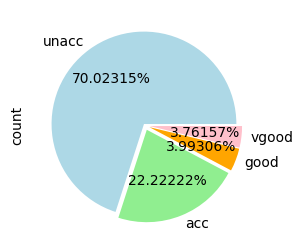

In [11]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] = 3
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie' , autopct='%0.05f%%',
                                   colors=['lightblue', 'lightgreen', 'orange', 'pink' ], explode=(0.02, 0.05, 0.05, 0.05))

> 딥러닝은 통계 알고리즘을 기반으로 하기 때문에 단어를 숫자(텐서)로 변환해야 함

> 가장 먼저 필요한 전처리: 데이터 파악

- 데이터를 범주형 타입으로 변환

In [12]:
categorical_columns = ['price', 'maint', 'doors', 'persons','lug_capacity', 'safety']

for category in categorical_columns:
  dataset[category] = dataset[category].astype('category') # astype() 메서드를 이용하여 데이터를 범주형으로 변환

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors , persons, lug_capacity, safety], 1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

> 범주형 데이터를 텐서로 변환하기 위해 필요한 절차

**범주형 데이터 -> dataset[category] -> 넘파이 배열(NumPy array) -> 텐서(Tensor)**


> 범주형 데이터(단어)를 숫자(넘파이 배열)로 변환하기 위해 cat.codes 사용 (cat.codes는 어떤 클래스가 어떤 숫자로 매핑되어 있는지 확인이 어려운 단점이 있으므로 주의해서 사용해야 함)

> np.stack 과 np.concatenate
넘파이 객체를 합칠 때 사용하는 메서드
- np.stack : 우 개 이상의 넘파이 객체를 합칠 때 사용 (새로운 축으로 합침. 따라서 반드시 두 배열의 차원이 동일해야 함)
- np.concatenate : 선택한 축을 기준으로 두 개의 배열을 연결

- 배열을 텐서로 변환

In [13]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

- 레이블로 사용할 칼럼을 텐서로 변환

In [14]:
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch. tensor(outputs).flatten()

print(categorical_data.shape)
print (outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


> get_dummies : 가변수(dummy variable)로 만들어주는 함수. 이는 문자를 숫자 (0,1)로 바꾸어 준다는 의미

> ravel(), reshape(), flatten() : 텐서의 차원을 바꿀 때 사용

> 워드 임베딩 : 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법
- 높은 차원의 임베딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있기에 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용함

- 범주형 칼럼을 N차원으로 변환

In [15]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in
                            categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size+1)//2)) for col_size in
                               categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


- 데이터셋 분리 (훈련과 테스트 용도로)

In [16]:
total_records = 1728
test_records = int (total_records * .2)
categorical_train_data = categorical_data[:total_records - test_records]
categorical_test_data = categorical_data[total_records - test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

- 데이터셋 분리 확인

In [17]:
print(len (categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


- 모델의 네트워크 생성

In [20]:
class Model(nn.Module):
  def __init__(self, embedding_size, output_size, layers, p=0.4):
    super().__init__()
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni,
                                          nf in embedding_size])
    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols # 입력츠으이 크기를 찾기 위해 범주형 칼럼 개수를 input_size 변수에 저장

    for i in layers:
      all_layers.append (nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True ))
      all_layers.append (nn.BatchNorm1d(i))
      all_layers.append (nn.Dropout(p))
      input_size = i

    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn. Sequential (*all_layers) # 신경망의 모든 계층이 순차적으로 실행되도록 모든 계층에 대한 목록(all_layers)을 nn.Sequential 클래스로 전달

  def forward (self, x_categorical):
    embeddings = []
    for i,e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:,i]))

    x = torch.cat(embeddings, 1) # 넘파이의 concatenate와 같지만 대상이 텐서가 됨
    x = self.embedding_dropout(x)
    x = self.layers(x)
    return x

>  __init__() : 모델에서 사용될 파라미터와 신경망을 초기화하기 위한 용도로 사용하며, 객체가 생성될 때 자동으로 호출됨
- def __init__(self, embedding_size, output_size, layers, p-0.4)
    - self : 첫 번째 파라미터는 self를 지정해야 하며, 자기 자신을 의미함
    - embedding_size = 범주형 칼럼의 임베딩 크기
    - output_size : 출력층의 크기
    - layers : 모든 계층에 대한 목록
    - p : 드롭아웃(기본값은 0.5)
- for 문을 이용해 각 계층을 all_layers 목록에 추가함. 추가된 계층은 다음과 같음
    - Linear : 선형 계층(linear layer)은 입력 데이터에 선형 변환을 진행한 결과. 선형 변환을 위해서는 $y=Wx+b$ 사용
    - ReLU : 활성화 함수로 사용
    - BatchNorm1d : 배치 정규화(batch normalization) 용도로 사용
    - Dropout : 과적합 방지에 사용

- Model 클래스의 객체 생성

In [21]:
model = Model(categorical_embedding_sizes, 4, [200, 100, 50] , p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


> 모델을 훈련시키기 전에 손실 함수와 옵티마이저에 대해 정의해야 함. 이번 예제는 **데이터를 분류해야 하는 것으로 크로스 엔트로피(corss entropy) 손실 함수를 사용하고 옵티마이저로는 아담(Adam)**을 사용함

- 모델의 파라미터 정의

In [22]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters() , lr=0.001)

- 파이토치는 GPU에 최적화된 답러닝 프레임워크. 하지만 GPU가 없다면 CPU를 사용할 수 있도록 지정해 주어야 함.
-  GPU가 있다면 GPU를 시용하고， 없다면 CPU를 사용 하도록 하는 코드


- CPU/GPU 사용 지정

In [24]:
if torch.cuda.is_available():
  device = torch.device('cuda') # GPU가 있다면 GPU를 사용
else:
  device = torch.device('cpu') # GPU가 없다면 CPU를 사용

- 모델 학습

In [25]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range (epochs):
  i += 1
  y_pred = model(categorical_train_data).to(device)
  single_loss = loss_function(y_pred, train_outputs)
  aggregated_losses.append(single_loss)

  if i%25 == 1:
    print(f'epoch: {i:3} loss: {single_loss.item() :10.8f}')

  optimizer.zero_grad()
  single_loss.backward()
  optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item() :10.10f}')

epoch:   1 loss: 1.72629094
epoch:  26 loss: 1.53677678
epoch:  51 loss: 1.42876029
epoch:  76 loss: 1.28930330
epoch: 101 loss: 1.14572489
epoch: 126 loss: 1.00785005
epoch: 151 loss: 0.87037402
epoch: 176 loss: 0.77254319
epoch: 201 loss: 0.70875198
epoch: 226 loss: 0.67340332
epoch: 251 loss: 0.66304725
epoch: 276 loss: 0.63188845
epoch: 301 loss: 0.61986703
epoch: 326 loss: 0.59494096
epoch: 351 loss: 0.60425389
epoch: 376 loss: 0.58918911
epoch: 401 loss: 0.58809167
epoch: 426 loss: 0.58816242
epoch: 451 loss: 0.57629198
epoch: 476 loss: 0.57629454
epoch: 500 loss: 0.5776991844


- 테스트 데이터셋으로 모델 예측

In [26]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_val, test_outputs)
print(f'Loss: {loss:.8f}')

Loss: 0.58068019


> 테스트 용도의 데이터셋에 대한 손실 값을 보여줌. 이 값은 훈련 데이터셋에서 도출된 손실 값과 비슷하므로 과적합은 발생하지 않았다고 판단할 수 있다.

- 모델의 예측 확인

In [27]:
print(y_val[:5])

tensor([[ 1.8890,  0.9748, -2.5152, -2.8042],
        [ 3.0998,  1.8455, -3.7616, -3.7415],
        [ 3.1599,  2.2734, -3.5059, -3.6621],
        [ 1.9591,  1.5017, -2.0508, -1.8814],
        [ 2.0713,  1.2963, -3.1729, -3.3948]])


> 실제 출력이 0이면 인덱스 0의 값이 인덱스 1의 값보다 높아야 함
- 가장 큰 값을 갖는 인덱스 확인 (실제 값이 아닌 인덱스 찾기)

In [28]:
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


> 인덱스가 0인 값이 인덱스가 1인 값보다 크므로 처리된 출력이 0임을 확인할 수 있음
- 테스트 데이터셋을 이용한 정확도 확인
    - sklearn.metrics 모듈의 classification_report, confusion_matrix, accuracy_score 클래스를 사용해 정확도, 정밀도와 재현율을 알아보자

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs,y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[259   0]
 [ 86   0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.00      0.00      0.00        86

    accuracy                           0.75       345
   macro avg       0.38      0.50      0.43       345
weighted avg       0.56      0.75      0.64       345

0.7507246376811594


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


> 신경망에서 필요한 모든 파라미터를 무작위로 선택했다는 것을 감안할 때 75%의 정확도는 나쁘지 않음. 파라미터(훈련/테스트 데이터셋 분할, 은닉층 개수 및 크기 등)를 변경하면서 더 나은 성능을 찾아보는 것도 학습에 도움이 될 것임

#### **딥러닝 분류 모델의 성능 평가 지표 알아보기**
- 필요한 용어들
    - True Positive : 모델(분류기)이 '1'이라고 예측했는데 실제 값도 '1'인 경우
    - True Negative : 모델(분류기)이 '0'이라고 예측했는데 실제 값도 '0'인 경우
    - False Positive : 모델(분류기)이 '1'이라고 예측했는데 실제 값은 '0'인 경우로, Type I 오류라고도 함
    - False Negative : 모델(분류기)이 '0'이라고 예측했는데 실제 값은 '1'인 경우로, Type II 오류라고도 함

**정확도**
- 전체 예측 건수에서 정답을 맞힌 건수의 비율. 이때 맞힌 정답이 positive이든 negative이든 상관 X

$$(True Positive + True Negative)/(True Positive + True Negative + False Positive + False Negative)$$

**재현율**
- 실제로 정답이 1이라고 할 때 모델(분류기)도 1로 예측한 비율. 따라서 처음부터 데이터가 1일 확률이 적을 때 사용하면 좋음

$$True Positive/(True Positive + False Negative)$$

**정밀도**
- 모델(분류기)이 1이라고 예측한 것 중에서 실제로 정답이 1인 비율

$$True Positive/(True Positive + False Positive)$$

**F1-스코어**
- 일반적으로 정밀도와 재현율은 trade-off 관계. 이를 해결하려고 정밀도와 재현율의 조화 평균(harmonic mean)을 이용한 것이 F1-스코어 평가이다. 이때 조화 평균은 다음 공식으로 구할 수 있다.

$$2 * (Precision * Recall)/(Precision + Recall)$$